# Cross-validation: guia prático para treino e avaliação

Este notebook explica **cross-validation**, ou **validação cruzada**, com exemplos em Python para você treinar.

A ideia central é simples: em vez de avaliar um modelo uma única vez com uma divisão fixa entre treino e teste, usamos várias divisões dos dados. Assim, conseguimos estimar melhor como o modelo deve se comportar em dados novos.

## 1. Por que validação cruzada existe?

Quando treinamos um modelo de Machine Learning, queremos saber se ele aprendeu padrões úteis ou se apenas decorou os dados de treino.

Uma divisão comum é:

- **Treino**: dados usados para ajustar o modelo.
- **Teste**: dados separados para avaliar o modelo.

O problema é que uma única divisão pode ser injusta. Por sorte ou azar, o conjunto de teste pode ficar fácil demais, difícil demais, pequeno demais ou pouco representativo.

A validação cruzada reduz esse risco porque avalia o modelo em várias divisões diferentes.

## 2. Conceito principal: K-Fold Cross-Validation

No método **K-Fold**, dividimos o dataset em `k` partes, chamadas de *folds*.

Exemplo com `k = 5`:

1. O modelo treina em 4 partes e testa na parte restante.
2. Esse processo se repete 5 vezes.
3. Cada parte vira conjunto de teste uma vez.
4. No fim, calculamos a média das métricas.

Isso gera uma avaliação mais estável do desempenho do modelo.

## 3. Instalando e importando bibliotecas

Se você ainda não tiver as bibliotecas instaladas, rode no terminal:

```bash
pip install numpy pandas scikit-learn matplotlib seaborn
```

Agora vamos importar o que será usado no notebook.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report

from sklearn.datasets import load_iris, load_breast_cancer, make_regression
from sklearn.model_selection import(
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    learning_curve
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid')
np.random.seed(42)

## 4. Exemplo inicial sem cross-validation

Primeiro vamos usar uma divisão simples: treino e teste.

Usaremos o dataset **Iris**, um conjunto clássico para classificação de espécies de flores.

In [11]:
iris = load_iris()

X = iris.data
y = iris.target

df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['target'] = y
df_iris['species'] = df_iris['target'].map(dict(enumerate(iris.target_names)))

df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Acurácia no teste: {accuracy:.3f}')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Acurácia no teste: 0.967
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Essa avaliação funciona, mas depende de uma única divisão. Se mudarmos o `random_state`, o resultado pode mudar.

Vamos testar isso.

In [14]:
resultados = []

for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed,
        stratify=y
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultados.append(accuracy_score(y_test, y_pred))

pd.DataFrame({'random_state': range(10), 'accuracy': resultados})

,random_state,accuracy
0,0,1.000000
1,1,0.966667
2,2,1.000000
3,3,0.900000
4,4,1.000000
5,5,0.966667
6,6,0.966667
7,7,1.000000
8,8,0.966667
9,9,0.966667


In [15]:
print(f"Média: {np.mean(resultados):3f}")
print(f"Desvio padrão: {np.std(resultados):3f}")
print(f"Menor resultado: {np.min(resultados):3f}")
print(f"Maior resultado: {np.max(resultados):3f}")

Média: 0.973333
Desvio padrão: 0.029059
Menor resultado: 0.900000
Maior resultado: 1.000000


## 5. Cross-validation com `cross_val_score`

Agora vamos avaliar o mesmo modelo com validação cruzada.

`cross_val_score` faz o processo automaticamente:

- separa os folds;
- treina o modelo várias vezes;
- avalia cada rodada;
- retorna uma pontuação para cada fold.

In [16]:
model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print('Scores em cada fold:', scores)
print(f'Média: {scores.std():3f}')
print(f'Desvio padrão: {scores.std():.3f}')

Scores em cada fold: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Média: 0.024944
Desvio padrão: 0.025


A média indica o desempenho esperado. O desvio padrão indica a estabilidade.

Um modelo com média alta e desvio baixo costuma ser mais confiável do que um modelo com média alta e desvio muito alto.

## 6. Visualizando os resultados dos folds

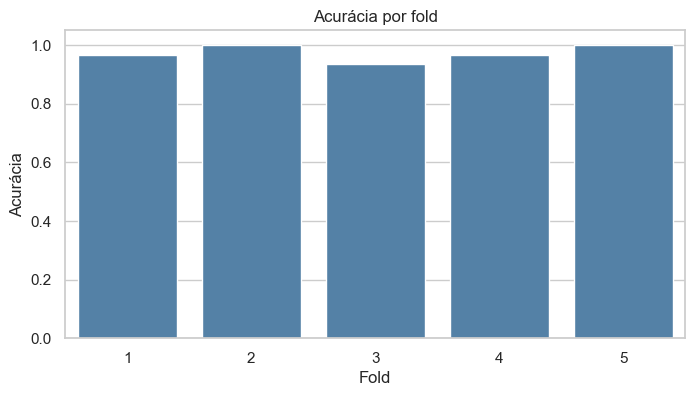

In [17]:
df_scores = pd.DataFrame({
    'fold':np.arange(1, len(scores) + 1),
    'accuracy':scores
})

plt.figure(figsize=(8,4))
sns.barplot(data=df_scores, x='fold', y='accuracy', color='steelblue')
plt.ylim(0, 1.05)
plt.title('Acurácia por fold')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.show()